#### Aproximacion modelos numpyro

In [1]:
import pandas as pd
import numpy as np
import jax.numpy as jnp
import jax
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from sklearn.preprocessing import LabelEncoder
from numpyro.infer import Predictive
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_parquet("../../../data/Train/train_final.parquet")
df_test = pd.read_parquet("../../../data/Train/test_final.parquet")

df_train.head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,...,parado,runway,fecha_despegue,hora_despegue,timestamp,tiempo_esperado,runway_occupied,queue_length,time_since_free,hold_pt_occupied
0,4ca570,2024-11-19 16:00:24.632,2024-11-19 16:02:21.404,2024-11-19 16:04:05.728,206.096,Medium 2 (between 34000 kg to 136000 kg),-3.560928,40.499439,-3.560366,40.499516,...,True,18L/36R,2024-11-19,16,2024-11-19 16:00:39.632,15.0,1.0,1.0,64.595,0
1,34604e,2024-12-10 07:12:44.411,2024-12-10 07:18:10.683,2024-12-10 07:19:48.626,314.215,Heavy (larger than 136000 kg),-3.560912,40.500307,-3.560318,40.500378,...,True,18L/36R,2024-12-10,7,2024-12-10 07:14:34.411,110.0,1.0,1.0,25.027,0
2,34310d,2024-11-13 16:01:57.720,2024-11-13 16:05:04.139,2024-11-13 16:07:08.595,130.875,High vortex aircraft,-3.576050,40.491765,-3.575628,40.491963,...,True,18R/36L,2024-11-13,16,2024-11-13 16:04:57.720,180.0,1.0,1.0,112.656,0
3,345205,2025-01-21 15:01:32.554,2025-01-21 15:03:43.598,2025-01-21 15:06:19.917,257.363,Medium 2 (between 34000 kg to 136000 kg),-3.560928,40.499416,-3.560364,40.499496,...,True,18L/36R,2025-01-21,15,2025-01-21 15:02:02.554,30.0,1.0,1.0,17.209,0
4,34324e,2025-01-13 18:56:49.328,2025-01-13 18:56:54.686,2025-01-13 18:57:37.817,48.489,Medium 2 (between 34000 kg to 136000 kg),-3.560928,40.499428,-3.560366,40.499481,...,False,18L/36R,2025-01-13,18,2025-01-13 18:56:49.328,0.0,0.0,0.0,125.038,0


In [3]:
print("TRAIN", df_train.shape[0])
print("TEST", df_test.shape[0])

TRAIN 258852
TEST 64713


Filtramos los datos por parado = True, ya que el avión tiene que estar parado

In [4]:
df_train = df_train[df_train.parado]
df_test = df_test[df_test.parado]

Como los datos están sampleados cada 5 segundos, nuestro siguiente estado se define como los siguientes 5 segundos, entonces sabemos si sale del punto de espera para despegar en los próximos 5 segundos. Lo pasamos a una columna boolean `took_off`, que toma valor true (1) si eso ocurre

para el train

In [5]:
df_train['took_off'] = 0
# para cada despegue calculamos el tiempo maximo esperado (nos permitirá encontrar la fila antes del despegue de las filas sampleadas)
antes_de_despegue = df_train.groupby('despegue')['tiempo_esperado'].max().reset_index()

# de esta forma para cada fila tendremos el tiempo_esperado maximo por despegue
df_train = df_train.merge(antes_de_despegue, on='despegue', suffixes=('', '_max'))

# took_off = 1, para aquellas filas donde el tiempo_esperado conincide con el maximo del despegue
df_train.loc[df_train['tiempo_esperado'] == df_train['tiempo_esperado_max'], 'took_off'] = 1

df_train = df_train.drop(columns=['tiempo_esperado_max'])
print(df_train['took_off'].value_counts())

took_off
0    161538
1      9477
Name: count, dtype: int64


para el test

In [6]:
df_test['took_off'] = 0
antes_de_despegue = df_test.groupby('despegue')['tiempo_esperado'].max().reset_index()
df_test = df_test.merge(antes_de_despegue, on='despegue', suffixes=('', '_max'))
df_test.loc[df_test['tiempo_esperado'] == df_test['tiempo_esperado_max'], 'took_off'] = 1
df_test = df_test.drop(columns=['tiempo_esperado_max'])
print(df_test['took_off'].value_counts())

took_off
0    33885
1     8741
Name: count, dtype: int64


#### Apartado A

In [21]:
data = df_train#.iloc[:1000]
data_test = df_test#.iloc[:1000]

Las columnas que usamos para el modelo son:
- aircraft_type
- holding_point
- runway_occupied
- hold_pt_occupied
- queue_length

Variable explicativa: took_off

In [22]:
# codificamos las categóricas como índices
le_aircraft = LabelEncoder()
le_holding = LabelEncoder()

data['aircraft_type_idx'] = le_aircraft.fit_transform(data['aircraft_type'])
data['holding_point_idx'] = le_holding.fit_transform(data['holding_point'])

data_test['aircraft_type_idx'] = le_aircraft.transform(data_test['aircraft_type'])
data_test['holding_point_idx'] = le_holding.transform(data_test['holding_point'])


Definimos el modelo de regresión logística en NumPyro

In [23]:
def logistic_regression_model(aircraft_type_idx, holding_point_idx,
                               runway_occupied, hold_pt_occupied,
                               queue_length, took_off=None,
                               n_aircraft_types=None, n_holding_points=None):
    
    # NO calcular dentro del modelo: JAX necesita saberlo antes.
    aircraft_type_effect = numpyro.sample("aircraft_type_effect", dist.Normal(0., 1.).expand([n_aircraft_types]))
    holding_point_effect = numpyro.sample("holding_point_effect", dist.Normal(0., 1.).expand([n_holding_points]))
    
    beta_runway_occupied = numpyro.sample("beta_runway_occupied", dist.Normal(0., 1.))
    beta_hold_pt_occupied = numpyro.sample("beta_hold_pt_occupied", dist.Normal(0., 1.))
    beta_queue_length = numpyro.sample("beta_queue_length", dist.Normal(0., 1.))
    intercept = numpyro.sample("intercept", dist.Normal(0., 5.))
    
    logits = (intercept 
              + aircraft_type_effect[aircraft_type_idx]
              + holding_point_effect[holding_point_idx]
              + beta_runway_occupied * runway_occupied
              + beta_hold_pt_occupied * hold_pt_occupied
              + beta_queue_length * queue_length)
    
    with numpyro.plate("data", logits.shape[0]):
        numpyro.sample("obs", dist.Bernoulli(logits=logits), obs=took_off)

In [24]:
def fit_model(data):
    aircraft_type_idx = jnp.array(data['aircraft_type_idx'].values)
    holding_point_idx = jnp.array(data['holding_point_idx'].values)
    runway_occupied = jnp.array(data['runway_occupied'].values)
    hold_pt_occupied = jnp.array(data['hold_pt_occupied'].values)
    queue_length = jnp.array(data['queue_length'].values)
    took_off = jnp.array(data['took_off'].values)

    nuts_kernel = NUTS(logistic_regression_model)
    mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=1)

    n_aircraft_types = data['aircraft_type_idx'].nunique()
    n_holding_points = data['holding_point_idx'].nunique()

    mcmc.run(
        jax.random.PRNGKey(0),
        aircraft_type_idx=aircraft_type_idx,
        holding_point_idx=holding_point_idx,
        runway_occupied=runway_occupied,
        hold_pt_occupied=hold_pt_occupied,
        queue_length=queue_length,
        took_off=took_off,
        n_aircraft_types=n_aircraft_types,
        n_holding_points=n_holding_points
    )
    
    return mcmc


In [ ]:
model_full = fit_model(data)

Evaluamos el modelo usando datos test

In [12]:
def predict(data, model):
    aircraft_type_idx_test = jnp.array(data['aircraft_type_idx'].values)
    holding_point_idx_test = jnp.array(data['holding_point_idx'].values)
    runway_occupied_test = jnp.array(data['runway_occupied'].values)
    hold_pt_occupied_test = jnp.array(data['hold_pt_occupied'].values)
    queue_length_test = jnp.array(data['queue_length'].values)
    n_aircraft_types = data['aircraft_type_idx'].nunique()
    n_holding_points = data['holding_point_idx'].nunique()

    predictive = Predictive(
        logistic_regression_model,
        posterior_samples=model.get_samples(),  # usamos las muestras que aprendimos
        return_sites=["obs"]  # solo queremos la predicción de 'obs'
    )

    return predictive(
        jax.random.PRNGKey(0),
        aircraft_type_idx=aircraft_type_idx_test,
        holding_point_idx=holding_point_idx_test,
        runway_occupied=runway_occupied_test,
        hold_pt_occupied=hold_pt_occupied_test,
        queue_length=queue_length_test,
        took_off=None,  # porque ahora queremos predecir
        n_aircraft_types=n_aircraft_types,
        n_holding_points=n_holding_points
    )


In [13]:
preds = predict(data, model_full)

In [14]:
# Convertimos las predicciones a clases
# preds['obs'] tiene forma (n_samples_mcmc, n_test)
# Tomamos el promedio sobre muestras → probabilidad media de took_off
probs_pred = preds['obs'].mean(axis=0)

# Si probabilidad > 0.5, predecimos 1
y_pred = (probs_pred > 0.5).astype(int)

# Calculamos accuracy
y_real = jnp.array(data['took_off'].values)

accuracy = (y_pred == y_real).mean()

print(f"Accuracy en TRAIN: {accuracy:.3f}")

Accuracy en TRAIN: 0.945


In [15]:
preds = predict(data_test, model_full)

In [16]:
# Convertimos las predicciones a clases
# preds['obs'] tiene forma (n_samples_mcmc, n_test)
# Tomamos el promedio sobre muestras → probabilidad media de took_off
probs_pred = preds['obs'].mean(axis=0)

# Si probabilidad > 0.5, predecimos 1
y_pred = (probs_pred > 0.5).astype(int)

# Calculamos accuracy
y_real = jnp.array(data_test['took_off'].values)

accuracy = (y_pred == y_real).mean()

print(f"Accuracy en TEST: {accuracy:.3f}")

Accuracy en TEST: 0.795


#### Apartado B

Establecemos lista de festivos (que pueden caer un sábado/domingo)

In [26]:
festivos_espana = [
    "2024-11-01",  # Todos los Santos (nacional)
    "2024-12-06",  # Día de la Constitución Española (nacional)
    "2024-11-09",  # Virgen de la Almudena (local Madrid)
    "2024-12-08",  # Inmaculada Concepción (nacional)
    "2024-12-09",  # Traslado de la Inmaculada (cuando cae domingo)
    
    # Navidad (nacional) 21.12 - 7.01
    "2024-12-21",  
    "2024-12-22",  
    "2024-12-23",  
    "2024-12-24",  
    "2024-12-25",  
    "2024-12-26",
    "2024-12-27",
    "2024-12-28",
    "2024-12-29",
    "2024-12-30",
    "2024-12-31",
    "2025-01-01",
    "2025-01-02",
    "2025-01-03",
    "2025-01-04",
    "2025-01-05",
    "2025-01-06",
    "2025-01-07",
]

In [27]:
mask_weekend = data["despegue"].dt.weekday > 5
mask_holiday = data["despegue"].dt.date.astype(str).isin(festivos_espana)
weekend_data = data[mask_weekend]
holiday_data = data[mask_holiday]
normal_data = data[(~mask_weekend) & (~mask_holiday)]

print("TRAIN")
print("NORMAL", normal_data.shape)
print("FINDE", weekend_data.shape)
print("FESTIVO", holiday_data.shape)

TRAIN
NORMAL (108906, 24)
FINDE (23785, 24)
FESTIVO (47768, 24)


In [28]:
mask_weekend = data_test["despegue"].dt.weekday > 5
mask_holiday = data_test["despegue"].dt.date.astype(str).isin(festivos_espana)
test_weekend_data = data_test[mask_weekend]
test_holiday_data = data_test[mask_holiday]
test_normal_data = data_test[(~mask_weekend) & (~mask_holiday)]

print("TEST")
print("NORMAL", test_normal_data.shape)
print("FINDE", test_weekend_data.shape)
print("FESTIVO", test_holiday_data.shape)

TEST
NORMAL (26983, 24)
FINDE (5910, 24)
FESTIVO (12114, 24)


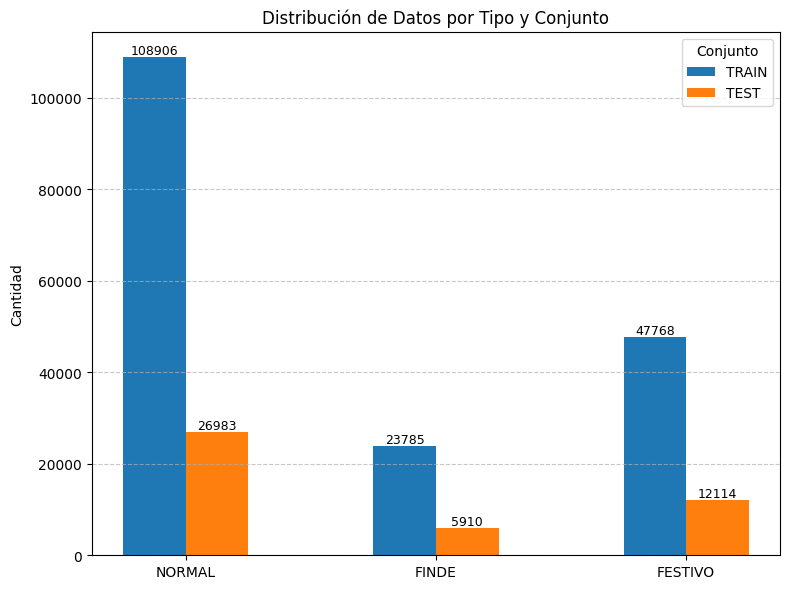

In [29]:
df = pd.DataFrame({
    "NORMAL": [normal_data.shape[0], test_normal_data.shape[0]],
    "FINDE": [weekend_data.shape[0], test_weekend_data.shape[0]],
    "FESTIVO": [holiday_data.shape[0], test_holiday_data.shape[0]],
}, index=["TRAIN", "TEST"])

bar_width = 0.25
x = np.arange(len(df.columns))
fig, ax = plt.subplots(figsize=(8, 6))

for i, label in enumerate(df.index):
    ax.bar(x + i * bar_width, df.loc[label], width=bar_width, label=label)

ax.set_xticks(x + bar_width / 2)
ax.set_xticklabels(df.columns)
ax.set_ylabel("Cantidad")
ax.set_title("Distribución de Datos por Tipo y Conjunto")
ax.legend(title="Conjunto")
ax.grid(axis='y', linestyle='--', alpha=0.7)

for i, label in enumerate(df.index):
    for j, value in enumerate(df.loc[label]):
        ax.text(j + i * bar_width, value + 0.5, str(value), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [30]:
# Entrena los tres modelos
mcmc_weekend = fit_model(weekend_data)
mcmc_holiday = fit_model(holiday_data)
mcmc_normal = fit_model(normal_data)

sample: 100%|██████████| 1500/1500 [1:30:51<00:00,  3.63s/it, 63 steps of size 2.06e-02. acc. prob=0.94] 


Guardamos los modelos

In [32]:
import pickle

with open("mcmc_normal.pkl", "wb") as f:
    pickle.dump(mcmc_normal.get_samples(), f)
with open("mcmc_weekend.pkl", "wb") as f:
    pickle.dump(mcmc_weekend.get_samples(), f)
with open("mcmc_holiday.pkl", "wb") as f:
    pickle.dump(mcmc_holiday.get_samples(), f)

with open("mcmc_full.pkl", "wb") as f:
    pickle.dump(model_full.get_samples(), f)

Para predecir a qué modelo pertenece usamos la siguiente función

In [33]:
def predict_model(mcmc_samples, new_data):
    # devuelve la probabilidad de clasificar correctamente el caso de entrenamiento, teniendo en cuenta took_off
    
    # Extraemos parámetros
    intercept = mcmc_samples['intercept'].mean()
    beta_runway_occupied = mcmc_samples['beta_runway_occupied'].mean()
    beta_hold_pt_occupied = mcmc_samples['beta_hold_pt_occupied'].mean()
    beta_queue_length = mcmc_samples['beta_queue_length'].mean()
    aircraft_type_effect = mcmc_samples['aircraft_type_effect'].mean(axis=0)
    holding_point_effect = mcmc_samples['holding_point_effect'].mean(axis=0)

    # Armamos el logit para el nuevo caso
    logit = (intercept
             + aircraft_type_effect[new_data['aircraft_type_idx']]
             + holding_point_effect[new_data['holding_point_idx']]
             + beta_runway_occupied * new_data['runway_occupied']
             + beta_hold_pt_occupied * new_data['hold_pt_occupied']
             + beta_queue_length * new_data['queue_length'])
    
    prob = jax.nn.sigmoid(logit)
    # si took_off es 0, tenemos que invertir la probabilidad
    if (not new_data["took_off"]):
        prob = 1 - prob

    return prob

In [34]:
# Nuevo caso (solo una fila, incluyendo la variable took_off)
new_case = weekend_data.iloc[0][['aircraft_type_idx', 'holding_point_idx', 'runway_occupied', 'hold_pt_occupied', 'queue_length', 'took_off']]

p_weekend = predict_model(mcmc_weekend.get_samples(), new_case)
p_holiday = predict_model(mcmc_holiday.get_samples(), new_case)
p_normal = predict_model(mcmc_normal.get_samples(), new_case)

# Normalizamos para obtener la probabilidad de pertenencia
probs = jnp.array([p_weekend, p_holiday, p_normal])
probs_normalized = probs / probs.sum()

print("CASO WEEKEND:")
print(new_case)
print()
print(f"Probabilidades de pertenencia:")
print(f"Weekend: {probs_normalized[0]:.3f}")
print(f"Holiday: {probs_normalized[1]:.3f}")
print(f"Normal : {probs_normalized[2]:.3f}")


CASO WEEKEND:
aircraft_type_idx      4
holding_point_idx      7
runway_occupied      1.0
hold_pt_occupied       0
queue_length         1.0
took_off               0
Name: 11, dtype: object

Probabilidades de pertenencia:
Weekend: 0.333
Holiday: 0.332
Normal : 0.334


In [35]:
# Nuevo caso (solo una fila, incluyendo la variable took_off)
new_case = holiday_data.iloc[0][['aircraft_type_idx', 'holding_point_idx', 'runway_occupied', 'hold_pt_occupied', 'queue_length', 'took_off']]

p_weekend = predict_model(mcmc_weekend.get_samples(), new_case)
p_holiday = predict_model(mcmc_holiday.get_samples(), new_case)
p_normal = predict_model(mcmc_normal.get_samples(), new_case)

# Normalizamos para obtener la probabilidad de pertenencia
probs = jnp.array([p_weekend, p_holiday, p_normal])
probs_normalized = probs / probs.sum()

print("CASO HOLIDAY:")
print(new_case)
print()
print(f"Probabilidades de pertenencia:")
print(f"Weekend: {probs_normalized[0]:.3f}")
print(f"Holiday: {probs_normalized[1]:.3f}")
print(f"Normal : {probs_normalized[2]:.3f}")


CASO HOLIDAY:
aircraft_type_idx      4
holding_point_idx      8
runway_occupied      1.0
hold_pt_occupied       0
queue_length         1.0
took_off               0
Name: 4, dtype: object

Probabilidades de pertenencia:
Weekend: 0.334
Holiday: 0.333
Normal : 0.332


In [36]:
# Nuevo caso (solo una fila, incluyendo la variable took_off)
new_case = normal_data.iloc[2][['aircraft_type_idx', 'holding_point_idx', 'runway_occupied', 'hold_pt_occupied', 'queue_length', 'took_off']]

p_weekend = predict_model(mcmc_weekend.get_samples(), new_case)
p_holiday = predict_model(mcmc_holiday.get_samples(), new_case)
p_normal = predict_model(mcmc_normal.get_samples(), new_case)

# Normalizamos para obtener la probabilidad de pertenencia
probs = jnp.array([p_weekend, p_holiday, p_normal])
probs_normalized = probs / probs.sum()

print("CASO NORMAL:")
print(new_case)
print()
print(f"Probabilidades de pertenencia:")
print(f"Weekend: {probs_normalized[0]:.3f}")
print(f"Holiday: {probs_normalized[1]:.3f}")
print(f"Normal : {probs_normalized[2]:.3f}")


CASO NORMAL:
aircraft_type_idx      1
holding_point_idx     11
runway_occupied      1.0
hold_pt_occupied       0
queue_length         1.0
took_off               0
Name: 2, dtype: object

Probabilidades de pertenencia:
Weekend: 0.342
Holiday: 0.326
Normal : 0.333


Vemos el accuracy en los datos train

In [37]:
accuracy_normal = 0
accuracy_holiday = 0
accuracy_weekend = 0
weekend_samples = mcmc_weekend.get_samples()
holiday_samples = mcmc_holiday.get_samples()
normal_samples = mcmc_normal.get_samples()
for i, row in normal_data.iterrows():
    p_weekend = predict_model(weekend_samples, row)
    p_holiday = predict_model(holiday_samples, row)
    p_normal = predict_model(normal_samples, row)
    if p_normal > p_weekend and p_normal > p_holiday:
        accuracy_normal += 1

for i, row in holiday_data.iterrows():
    p_weekend = predict_model(weekend_samples, row)
    p_holiday = predict_model(holiday_samples, row)
    p_normal = predict_model(normal_samples, row)
    if p_holiday > p_weekend and p_holiday > p_normal:
        accuracy_holiday += 1

for i, row in weekend_data.iterrows():
    p_weekend = predict_model(weekend_samples, row)
    p_holiday = predict_model(holiday_samples, row)
    p_normal = predict_model(normal_samples, row)
    if p_weekend > p_holiday and p_weekend > p_normal:
        accuracy_weekend += 1

print(f"Accuracy:")
print(f"Weekend: {accuracy_weekend / weekend_data.shape[0]} ({accuracy_weekend} / {weekend_data.shape[0]})")
print(f"Holiday: {accuracy_holiday / holiday_data.shape[0]} ({accuracy_holiday} / {holiday_data.shape[0]})")
print(f"Normal : {accuracy_normal / normal_data.shape[0]} ({accuracy_normal} / {normal_data.shape[0]})")


Accuracy:
Weekend: 0.3499684675215472 (8324 / 23785)
Holiday: 0.19330932842070006 (9234 / 47768)
Normal : 0.5018639928011313 (54656 / 108906)


Vemos el accuracy en los datos test

In [38]:
accuracy_normal = 0
accuracy_holiday = 0
accuracy_weekend = 0
weekend_samples = mcmc_weekend.get_samples()
holiday_samples = mcmc_holiday.get_samples()
normal_samples = mcmc_normal.get_samples()
for i, row in test_normal_data.iterrows():
    p_weekend = predict_model(weekend_samples, row)
    p_holiday = predict_model(holiday_samples, row)
    p_normal = predict_model(normal_samples, row)
    if p_normal > p_weekend and p_normal > p_holiday:
        accuracy_normal += 1

for i, row in test_holiday_data.iterrows():
    p_weekend = predict_model(weekend_samples, row)
    p_holiday = predict_model(holiday_samples, row)
    p_normal = predict_model(normal_samples, row)
    if p_holiday > p_weekend and p_holiday > p_normal:
        accuracy_holiday += 1

for i, row in test_weekend_data.iterrows():
    p_weekend = predict_model(weekend_samples, row)
    p_holiday = predict_model(holiday_samples, row)
    p_normal = predict_model(normal_samples, row)
    if p_weekend > p_holiday and p_weekend > p_normal:
        accuracy_weekend += 1

print(f"Accuracy:")
print(f"Weekend: {accuracy_weekend / test_weekend_data.shape[0]} ({accuracy_weekend} / {test_weekend_data.shape[0]})")
print(f"Holiday: {accuracy_holiday / test_holiday_data.shape[0]} ({accuracy_holiday} / {test_holiday_data.shape[0]})")
print(f"Normal : {accuracy_normal / test_normal_data.shape[0]} ({accuracy_normal} / {test_normal_data.shape[0]})")


Accuracy:
Weekend: 0.3431472081218274 (2028 / 5910)
Holiday: 0.21471025260029716 (2601 / 12114)
Normal : 0.4797465070600007 (12945 / 26983)
